**Exercise for k means tutorial**

Use iris flower dataset from sklearn library and try to form clusters of flowers using petal width and length features.

Drop other two features for simplicity.

Figure out if any preprocessing such as scaling would help here
Draw elbow plot and from that figure out optimal value of k

In [1]:
from numpy import load
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

In [2]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [3]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
x = df.drop(['sepal length (cm)','sepal width (cm)'], axis='columns')
x.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [5]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(x)
y_predicted

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [12]:
cm = confusion_matrix(iris.target, y_predicted)
cm

array([[ 0, 50,  0],
       [48,  0,  2],
       [ 4,  0, 46]])

Text(50.722222222222214, 0.5, 'Truth')

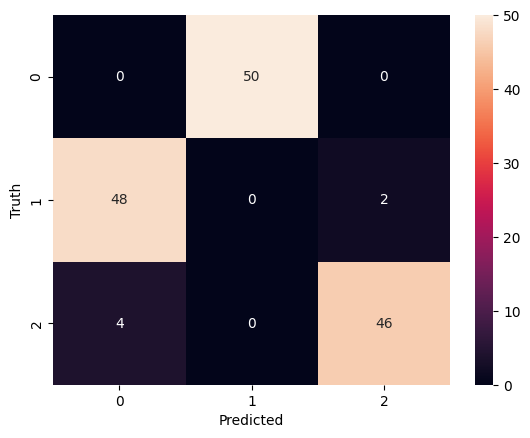

In [13]:
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

Text(0, 0.5, 'Petal Length')

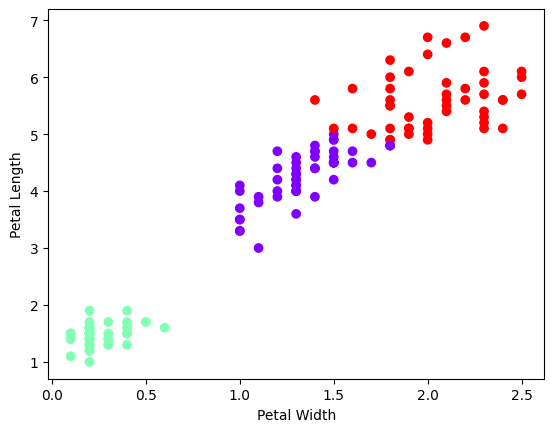

In [8]:
from matplotlib import pyplot as plt
%matplotlib inline
plt.scatter(df['petal width (cm)'],df['petal length (cm)'],c=y_predicted,cmap='rainbow')
plt.xlabel('Petal Width')
plt.ylabel('Petal Length')

In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
x_scaled

array([[0.06779661, 0.04166667],
       [0.06779661, 0.04166667],
       [0.05084746, 0.04166667],
       [0.08474576, 0.04166667],
       [0.06779661, 0.04166667],
       [0.11864407, 0.125     ],
       [0.06779661, 0.08333333],
       [0.08474576, 0.04166667],
       [0.06779661, 0.04166667],
       [0.08474576, 0.        ],
       [0.08474576, 0.04166667],
       [0.10169492, 0.04166667],
       [0.06779661, 0.        ],
       [0.01694915, 0.        ],
       [0.03389831, 0.04166667],
       [0.08474576, 0.125     ],
       [0.05084746, 0.125     ],
       [0.06779661, 0.08333333],
       [0.11864407, 0.08333333],
       [0.08474576, 0.08333333],
       [0.11864407, 0.04166667],
       [0.08474576, 0.125     ],
       [0.        , 0.04166667],
       [0.11864407, 0.16666667],
       [0.15254237, 0.04166667],
       [0.10169492, 0.04166667],
       [0.10169492, 0.125     ],
       [0.08474576, 0.04166667],
       [0.06779661, 0.04166667],
       [0.10169492, 0.04166667],
       [0.

In [7]:
y_pred = km.fit_predict(x_scaled)

Text(0, 0.5, 'Petal Length')

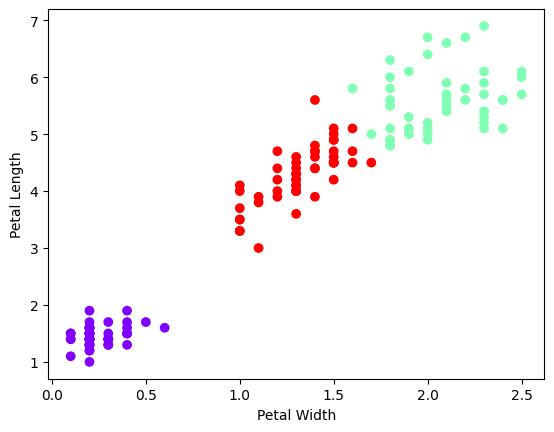

In [9]:
plt.scatter(df['petal width (cm)'],df['petal length (cm)'],c=y_pred,cmap='rainbow')
plt.xlabel('Petal Width')
plt.ylabel('Petal Length')

In [10]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(iris.target, y_pred)
cm

array([[50,  0,  0],
       [ 0,  2, 48],
       [ 0, 46,  4]])

Text(50.722222222222214, 0.5, 'Truth')

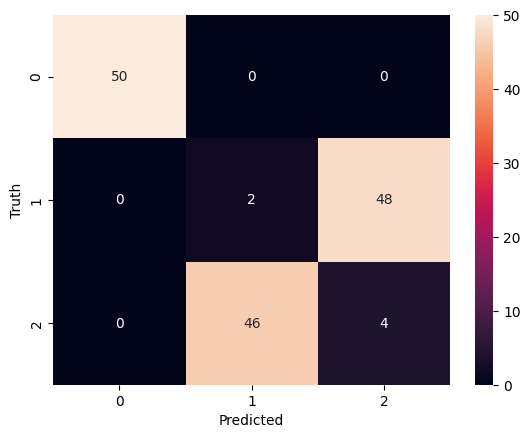

In [11]:
import seaborn as sn
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [14]:
sse = []
for k in range(1,11):
    km = KMeans(n_clusters=k)
    km.fit(x)
    sse.append(km.inertia_)

In [15]:
sse

[550.8953333333333,
 86.39021984551391,
 31.371358974358966,
 20.299607803485397,
 14.171085855554194,
 13.054867329973945,
 9.191170634920635,
 9.024638351056204,
 7.358382352941181,
 6.6631942959001815]

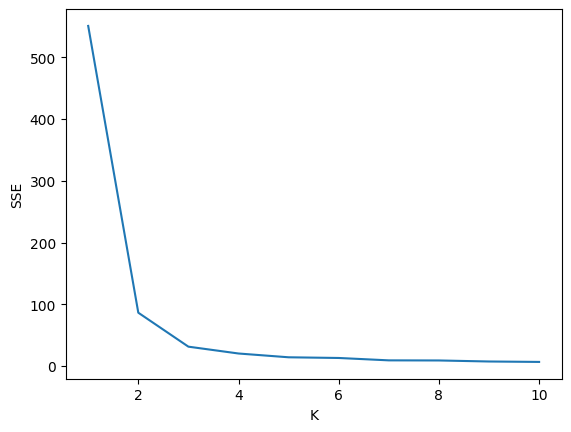

In [16]:
plt.plot(range(1,11),sse)
plt.xlabel('K')
plt.ylabel('SSE')
plt.show()

In [17]:
y_pred[100]

np.int32(1)

In [18]:
iris.target[100]

np.int64(2)